### Coefficient combinations for the ice sheet

PROMICE stations that achieved R2 of <.08 were excluded es well (compare Satellite coefficients on the ICE sheet). However, the ERA5 data resembels much better what PROMICE is measuring: Only one station with a R2 of 0.51 (TAS_L), all other at least 0.86. Filtered that one station (obs n=2489) out for the calculation of the overall calibration coefficients. 

After the exclusion of these stations, the script was ran again with a reduced aws_data dataset.

In [15]:
import pandas as pd
# import os
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import itertools
sns.set_theme(style="darkgrid")

# Show current working directory
# print("Current Working Directory: ", os.getcwd())


In [28]:
### LOAD ICE DATASETS (PROMICE AND ERA5)

# File paths
aws_path = '/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/PROMICE/output/daily_prepped.csv'
era5_path = '/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/ERA5/t2m_at_PROMICE_full.csv'

# Load data
aws_data = pd.read_csv(aws_path, index_col=0, parse_dates=True)
era5_data = pd.read_csv(era5_path, index_col=0, parse_dates=True)

# Filter to include only stations where the follonwing analysis revealed a good fit of min. r^2 0.8.
aws_data = aws_data[aws_data['aws'].isin(selected_stations)]

# Restructure ERA5 table to match with AWS table (preparation for merging)
era5_data = era5_data.reset_index().rename(columns={'index': 'date'})
era5_data_long = (
    era5_data
    .melt(id_vars=['date'], var_name='aws', value_name='t2m_era5')
    .dropna(subset=['t2m_era5'])  # Drop rows where t2m_era5 is NaN
    .sort_values(by=['aws', 'date'], ignore_index=True)
)

# print(aws_data.head(), "\n")
# print(era5_data_long.head())

# Merge AWS and ERA5 data on 'date' and 'aws'
df = pd.merge(
    aws_data,
    era5_data_long,
    on=['aws', 'date'],
    how='inner'
)

print(df.head())

   t_surf       date       ulr       dlr        lat        lon  aws  year  \
0 -5.8494 2017-07-24  287.1386  210.9634  77.148373 -61.058915  CEN  2017   
1 -8.3668 2017-07-25  276.7981  204.9620  77.181856 -61.115329  CEN  2017   
2 -4.4096 2017-07-26  294.6909  252.6718  77.181856 -61.115329  CEN  2017   
3 -1.3757 2017-07-27  309.3202  294.0715  77.181856 -61.115330  CEN  2017   
4 -2.9410 2017-07-28  302.0211  263.2413  77.181856 -61.115330  CEN  2017   

   lat_yearly  lon_yearly  rad_temp  t2m_era5  
0   77.181644  -61.115006 -6.207523 -7.882355  
1   77.181644  -61.115006 -8.647817 -7.612061  
2   77.181644  -61.115006 -4.552368 -3.126709  
3   77.181644  -61.115006 -1.343175 -1.986786  
4   77.181644  -61.115006 -2.907106 -2.018768  


### Retrieve coefficients and make plots ICE
Regression between ERA5 data and PROMICE AWS measurements. Note, that ERA5 observations of +0 are excluded. In summer, some observations were above zero. However, it can be argued, that temperatures cannot be above 0 as only PROMICE stations on the icesheet were included here. 
ERA5 data was in 500m resolution.  


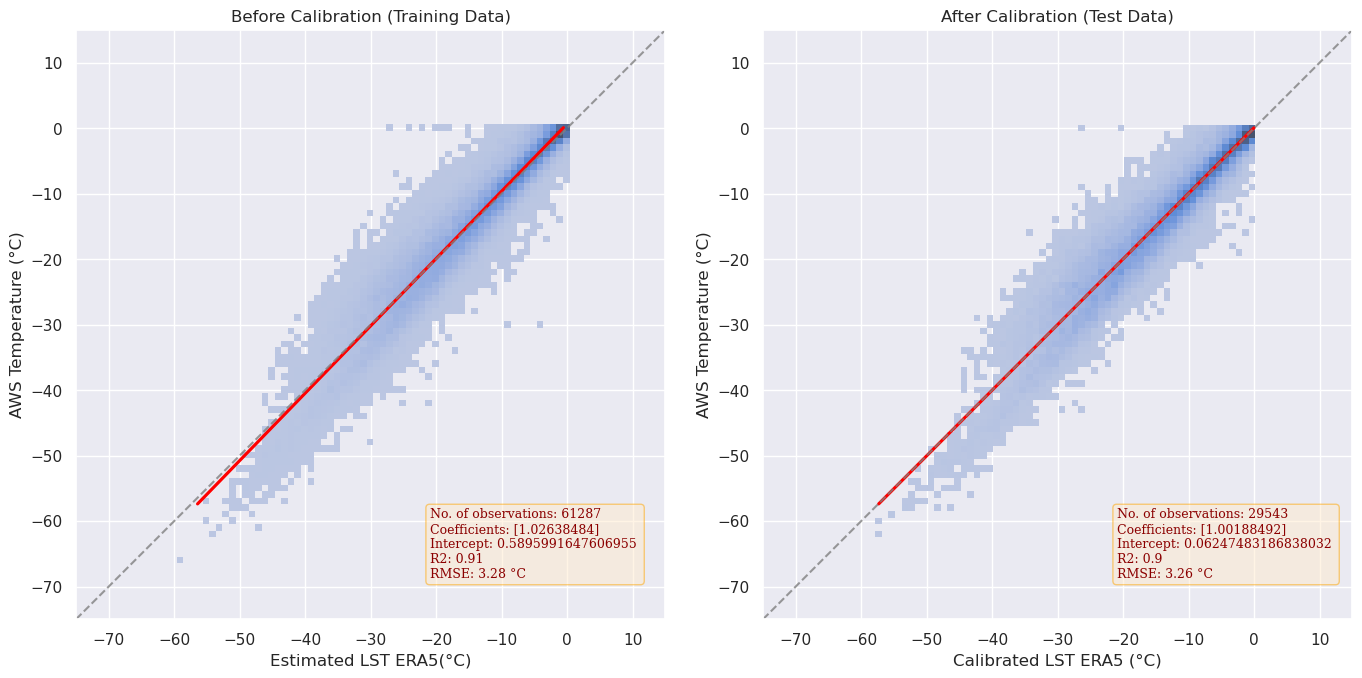

In [30]:
def split_mod_viz(df):

    # Only observations where t2m_era5 is <= 0 °C
    df = df[df['t2m_era5'] <= 0]

    # Split data into training and testing sets (2/3 training, 1/3 testing)
    train_df, test_df = train_test_split(df, test_size=0.33, random_state=42)

    # Regression model fit and prediction
    model = LinearRegression()
    model.fit(train_df[['t2m_era5']], train_df['t_surf'])
    model.predict(test_df[['t2m_era5']])
    r2_train = round(model.score(train_df[['t2m_era5']], train_df['t_surf']), 2)

    # return {
    #     "n_obs": len(df),
    #     "coef": model.coef_[0],
    #     "intercept": model.intercept_,
    #     'R-squared': model.score(test_df[['est_temp']], test_df['t_surf']),
    #     'rmse_before': ((test_df['est_temp'] - test_df['t_surf']) ** 2).mean() ** 0.5,
    #     'rmse_after': ((test_df['est_temp'] * model.coef_[0] + model.intercept_ - test_df['t_surf']) ** 2).mean() ** 0.5
    #     }

    # # The coefficients
    # print('No. of observations (total df): ', len(df))
    # print('Coefficients: ', model.coef_)
    # print('Intercept: ', model.intercept_)
    # print('R-squared: ', model.score(test_df[['est_temp']], test_df['t_surf']))

    # Apply calibration to test dataset
    test_df['lst_calibrated'] = test_df['t2m_era5'] * model.coef_[0] + model.intercept_
    test_df = test_df[test_df['lst_calibrated'] <= 0] 

    # Reveal coefficients of the calibrated model
    model2 = LinearRegression()
    model2.fit(test_df[['lst_calibrated']], test_df['t_surf'])
    r2_test = round(model2.score(test_df[['lst_calibrated']], test_df['t_surf']), 2)

    # Calculate RMSE of the calibration results
    rmse_before = ((test_df['t2m_era5'] - test_df['t_surf']) ** 2).mean() ** 0.5
    rmse_after = ((test_df['lst_calibrated'] - test_df['t_surf']) ** 2).mean() ** 0.5
    # print(f"RMSE before calibration: {rmse_before:.2f} °C")
    # print(f"RMSE after calibration: {rmse_after:.2f} °C\n")
    s1 = f'No. of observations: {len(train_df)} \nCoefficients: {model.coef_} \nIntercept: {model.intercept_} \nR2: {r2_train} \nRMSE: {rmse_before:.2f} °C'
    s2 = f'No. of observations: {len(test_df)} \nCoefficients: {model2.coef_} \nIntercept: {model2.intercept_} \nR2: {r2_test} \nRMSE: {rmse_after:.2f} °C'

    ### GRAPHICAL VISUALIZATION ###
    # Create comparison plot of original vs calibrated values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    # Add 1:1 reference line 
    min_val = -75
    max_val = 15

    # 
    font = {'family': 'serif',
            'color':  'darkred',
            'weight': 'normal',
            'size': 9,
            }
    
    bbox = dict(
        boxstyle='round', 
        fc='blanchedalmond', 
        ec='orange', 
        alpha=0.5)

    # 2d HISTOGRAM PLOTS
    # Original est_temp plot
    sns.histplot(ax=ax1, data=train_df, x='t2m_era5', y='t_surf', bins=60, discrete=True)
    sns.regplot(ax=ax1, data=test_df, x='t2m_era5', y='t_surf', scatter=False, color='red')
    ax1.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    ax1.text(0.6, 0.07, s1, fontdict=font, bbox=bbox, transform=ax1.transAxes, horizontalalignment='left')
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)
    ax1.set_xlabel('Estimated LST ERA5(°C)')
    ax1.set_ylabel('AWS Temperature (°C)')
    ax1.set_title('Before Calibration (Training Data)')
    ax1.set_aspect('equal')

    # Calibrated est_temp plot
    sns.histplot(ax=ax2, data=test_df, x='lst_calibrated', y='t_surf', bins=60, discrete=True)
    sns.regplot(ax=ax2, data=test_df, x='lst_calibrated', y='t_surf', scatter=False, color='red')
    ax2.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    ax2.text(0.6, 0.07, s2, fontdict=font, bbox=bbox, transform=ax2.transAxes, horizontalalignment='left')
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)
    ax2.set_xlabel('Calibrated LST ERA5 (°C)')
    ax2.set_ylabel('AWS Temperature (°C)')
    ax2.set_title('After Calibration (Test Data)')
    ax2.set_aspect('equal')
    plt.tight_layout()
    plt.show()

split_mod_viz(df)


In [ ]:
#%% different scale plots - Shunan
# Integrate this chunk into the plots to make colorbars aligned with the jointplot
sns.set_theme(style="darkgrid", font="Arial", font_scale=2)
g = sns.jointplot(x="visnirAlbedo", y="Albedo_theta<70d", data=df, kind="hist", 
                  height=8, xlim=(0,1), ylim=(0,1), cbar=True, vmin=0, vmax=55)
g.ax_joint.axline((0, 0), (1, 1), linewidth=1, color='k', linestyle='--')                       
g.plot_joint(sns.regplot, color='r', scatter=False)
g.set_axis_labels(xlabel="visnir albedo", ylabel="PROMICE albedo")

# ref https://stackoverflow.com/a/60849048/13318759
# get the current positions of the joint ax and the ax for the marginal x
pos_joint_ax = g.ax_joint.get_position()
pos_marg_x_ax = g.ax_marg_x.get_position()
# reposition the joint ax so it has the same width as the marginal x ax
g.ax_joint.set_position([pos_joint_ax.x0, pos_joint_ax.y0, pos_marg_x_ax.width, pos_joint_ax.height])
# reposition the colorbar using new x positions and y positions of the joint ax
g.fig.axes[-1].set_position([.96, pos_joint_ax.y0, .07, pos_joint_ax.height])


### Coefficients per station

In [31]:
# COEFFICIENTS AND NSE FOR EACH STATION AND ALL SENSORS AS TABLE
stations = df['aws'].unique()

# Calculate NSE for every station in order to compare the goodness of fit across stations
def nse(df):
    """Nash-Sutcliffe Efficiency (NSE) as per `Nash and Sutcliffe, 1970
    <https://doi.org/10.1016/0022-1694(70)90255-6>`_.
    :Calculation Details:
        .. math::
           E_{\\text{NSE}} = 1 - \\frac{\\sum_{i=1}^{N}[e_{i}-s_{i}]^2}
           {\\sum_{i=1}^{N}[e_{i}-\\mu(e)]^2}
        where *N* is the length of the *simulations* and *evaluation*
        periods, *e* is the *evaluation* series, *s* is (one of) the
        *simulations* series, and *μ* is the arithmetic mean.
    https://github.com/ThibHlln/hydroeval/tree/v0.1.0
    Thibault Hallouin, 2021. hydroeval: an evaluator for streamflow time series in Python. https://doi.org/10.5281/zenodo.4709652        
    """
    obs = df['t_surf'].to_numpy(dtype=np.float64)
    pred = df['lst_calibrated'].to_numpy(dtype=np.float64)
    
    nse_ = 1 - (
            np.sum((obs - pred) ** 2, axis=0, dtype=np.float64)
            / np.sum((obs - np.mean(obs)) ** 2, dtype=np.float64)
    )
    return nse_


def split_mod_df(df):

    df = df[df['t2m_era5'] <= 0]

    # Split data into training and testing sets (2/3 training, 1/3 testing)
    train_df, test_df = train_test_split(df, test_size=0.33, random_state=42)

    # Regression model fit and prediction
    model = LinearRegression()
    model.fit(train_df[['t2m_era5']], train_df['t_surf'])
    model.predict(test_df[['t2m_era5']])
    r2_train = round(model.score(train_df[['t2m_era5']], train_df['t_surf']), 2)

    # Apply calibration to test dataset
    test_df['lst_calibrated'] = test_df['t2m_era5'] * model.coef_[0] + model.intercept_
    test_df = test_df[test_df['lst_calibrated'] <= 0]

    # Reveal coefficients of the calibrated model
    model2 = LinearRegression()
    model2.fit(test_df[['lst_calibrated']], test_df['t_surf'])
    r2_test = round(model2.score(test_df[['lst_calibrated']], test_df['t_surf']), 2)

    # Calculate RMSE and NSE of the calibration results
    rmse_before = ((test_df['t2m_era5'] - test_df['t_surf']) ** 2).mean() ** 0.5
    rmse_after = ((test_df['lst_calibrated'] - test_df['t_surf']) ** 2).mean() ** 0.5
    nse_after = round(nse(test_df),2)

    return {
        "n_obs": len(df),
        "coef_before": model.coef_[0],
        "intercept_before": model.intercept_,
        'R-squared_before': r2_train,
        'rmse_before': rmse_before,
        "coef_calibrated": model2.coef_[0],
        "intercept_calibrated": model2.intercept_,
        "R-squared_after": r2_test,
        'rmse_after': rmse_after,
        "NSE": nse_after
        }


##### FOR EACH Station and all sensors

results_pr_staton = []

for station in stations:
    df_per_station = df[df['aws'] == station]
    results_pr_staton.append(split_mod_df(df_per_station))
    results_pr_staton[-1]['Station'] = station

df_results_station = pd.DataFrame(results_pr_staton)
df_results_station.sort_values(by='NSE', ascending=False, inplace=True)
print(df_results_station)
# df_results_station.to_csv('/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/PROMICE/output/Calibration_Stations/Coefficients_PROMICE_Stations_ERA5.csv', index=False)

# Use only stations with R-squared_after >= 0.8 for the final calibration results
selected_stations = df_results_station[df_results_station['R-squared_after'] >= 0.8]['Station'].tolist()

    n_obs  coef_before  intercept_before  R-squared_before  rmse_before  \
1    1153     1.156927          1.684729              0.97     2.512210   
0    2309     1.146889          1.269116              0.97     3.006179   
2     909     1.142072          1.297201              0.96     2.538717   
4     773     1.159917          1.486643              0.98     3.262281   
5     637     1.097775         -0.770918              0.97     2.657171   
12    612     1.134250          2.105047              0.97     3.084530   
34    866     1.148622          1.718032              0.97     3.076493   
13   1081     1.165190          1.628803              0.96     2.951459   
26   1083     1.145245          2.018695              0.95     2.479051   
9    5489     1.163758          1.517594              0.96     2.679109   
15   1063     1.149757          2.057147              0.96     2.842389   
19    440     1.092566          0.091158              0.95     2.035385   
28   1429     1.160724   

### Extract coefficients for all possible satellite combinations. 

In [32]:
results_with_filter = pd.DataFrame([split_mod_df(df)])
# results_with_filter.to_csv('/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/ERA5/coefficients_era5_ice.csv', index=False)

print(results_with_filter,'\n')

   n_obs  coef_before  intercept_before  R-squared_before  rmse_before  \
0  91474     1.026385          0.589599              0.91     3.280753   

   coef_calibrated  intercept_calibrated  R-squared_after  rmse_after  NSE  
0         1.001885              0.062475              0.9    3.262508  0.9   

